In [1]:
import pickle

load_path = r'D:\Dhika Ramadhan Saputra\Data Analist\Full Project\Market Basket Analysis (MBA) & Bundling Strategy\data\clean\one-hot_encoding.pkl'

with open(load_path, 'rb') as f:
    df_encoded = pickle.load(f)

print("Data OHE berhasil dimuat kembali!")

Data OHE berhasil dimuat kembali!


In [2]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. Mencari Frequent Itemsets (min_support yang kecil (0.01))
# karena dengan produk unik banyak, jarang ada satu produk yang muncul sangat masif di semua transaksi.
frequent_itemsets = fpgrowth(df_encoded, min_support=0.01, use_colnames=True)

# 2. Membuat Aturan Asosiasi (Association Rules)
# metrik 'lift' untuk melihat hubungan yang paling kuat
# min_threshold=1 = hanya mau hubungan yang positif >1
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 3. Merapikan Hasil
# urutkan berdasarkan Lift tertinggi dan Confidence tertinggi
rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])

# Tampilkan 10 hasil terbaik
rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
16,(Organic Raspberries),(Organic Strawberries),0.04275,0.08196,0.01015,0.237427,2.896863,0.006646,1.203871,0.684042
17,(Organic Strawberries),(Organic Raspberries),0.08196,0.04275,0.01015,0.123841,2.896863,0.006646,1.092553,0.713258
26,(Organic Fuji Apple),(Banana),0.02757,0.14875,0.01035,0.375408,2.523752,0.006249,1.362890,0.620882
27,(Banana),(Organic Fuji Apple),0.14875,0.02757,0.01035,0.069580,2.523752,0.006249,1.045151,0.709268
15,(Organic Raspberries),(Bag of Organic Bananas),0.04275,0.11961,0.01279,0.299181,2.501307,0.007677,1.256231,0.627014
14,(Bag of Organic Bananas),(Organic Raspberries),0.11961,0.04275,0.01279,0.106931,2.501307,0.007677,1.071865,0.681753
6,(Bag of Organic Bananas),(Organic Hass Avocado),0.11961,0.06585,0.01907,0.159435,2.421182,0.011194,1.111336,0.666726
7,(Organic Hass Avocado),(Bag of Organic Bananas),0.06585,0.11961,0.01907,0.289598,2.421182,0.011194,1.239283,0.628356
13,(Organic Hass Avocado),(Organic Strawberries),0.06585,0.08196,0.01229,0.186636,2.277163,0.006893,1.128696,0.600393
12,(Organic Strawberries),(Organic Hass Avocado),0.08196,0.06585,0.01229,0.149951,2.277163,0.006893,1.098937,0.610929


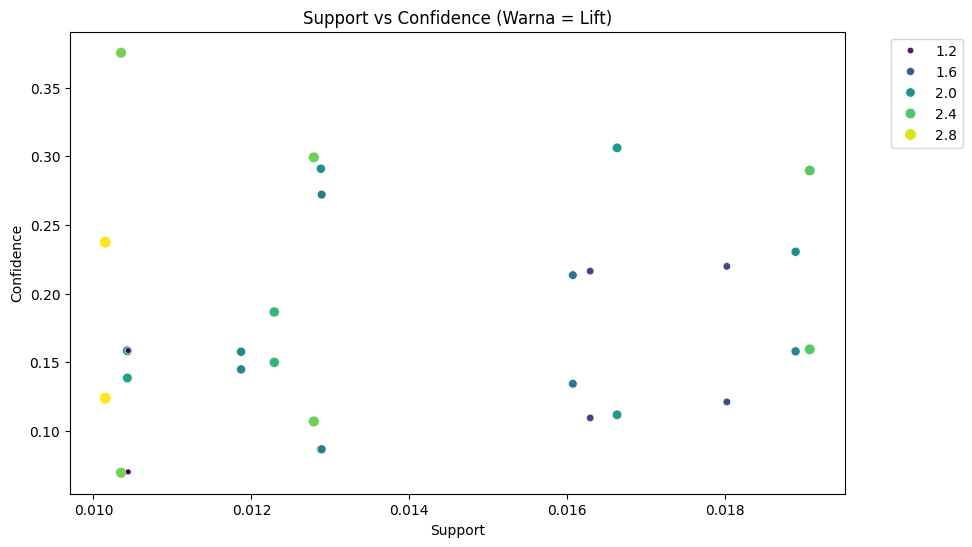

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", data=rules, palette="viridis")
plt.title("Support vs Confidence (Warna = Lift)")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

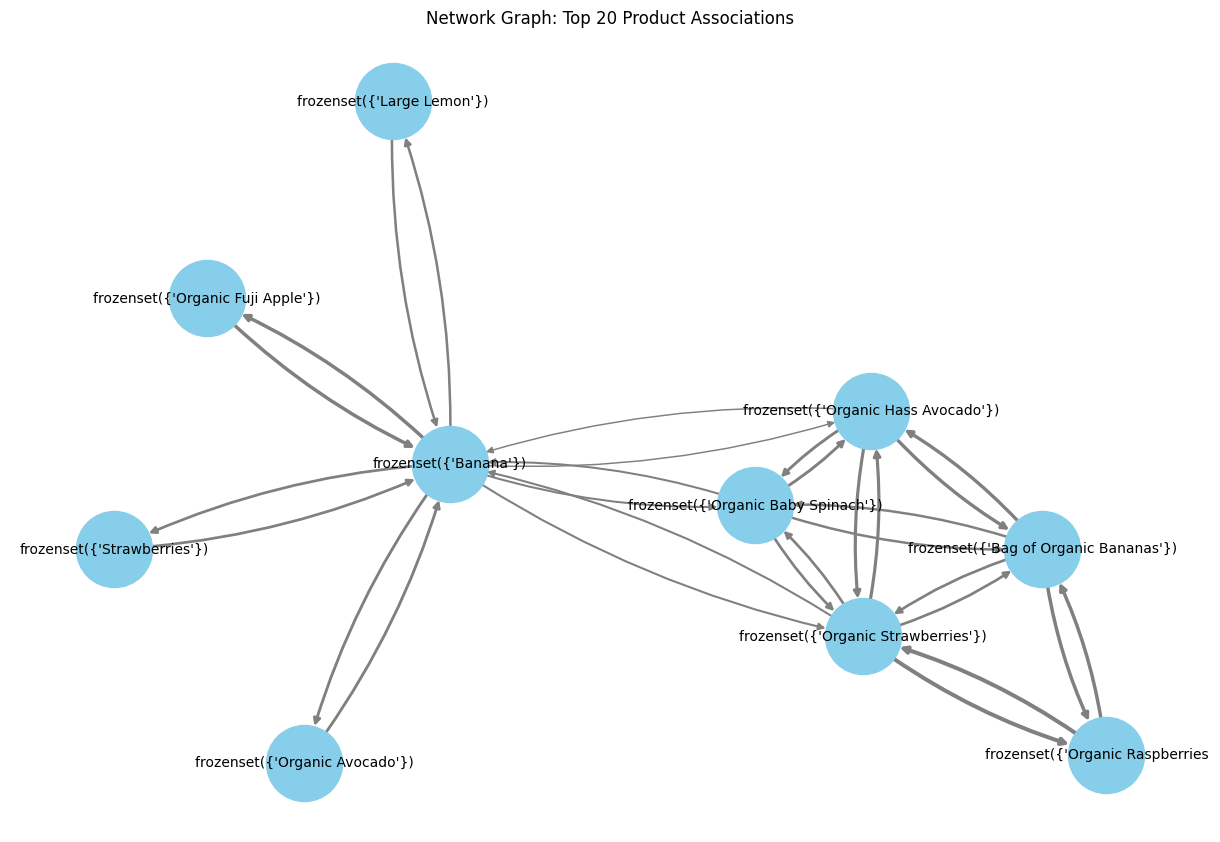

In [ ]:
import networkx as nx

top_rules = rules

# Inisialisasi grafik
G = nx.DiGraph()

# Tambahkan hubungan antar produk
for i, row in top_rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=row['lift'])

# Gambar grafik
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5)  # k mengatur jarak antar node

nx.draw(G, pos, with_labels=True, 
        node_color='skyblue', node_size=3000, 
        edge_color='gray', font_size=10, 
        width=[G[u][v]['weight'] for u,v in G.edges()], # Tebal garis sesuai Lift
        connectionstyle='arc3, rad=0.1')

plt.title("Network Graph: Top 20 Product Associations")
plt.show()

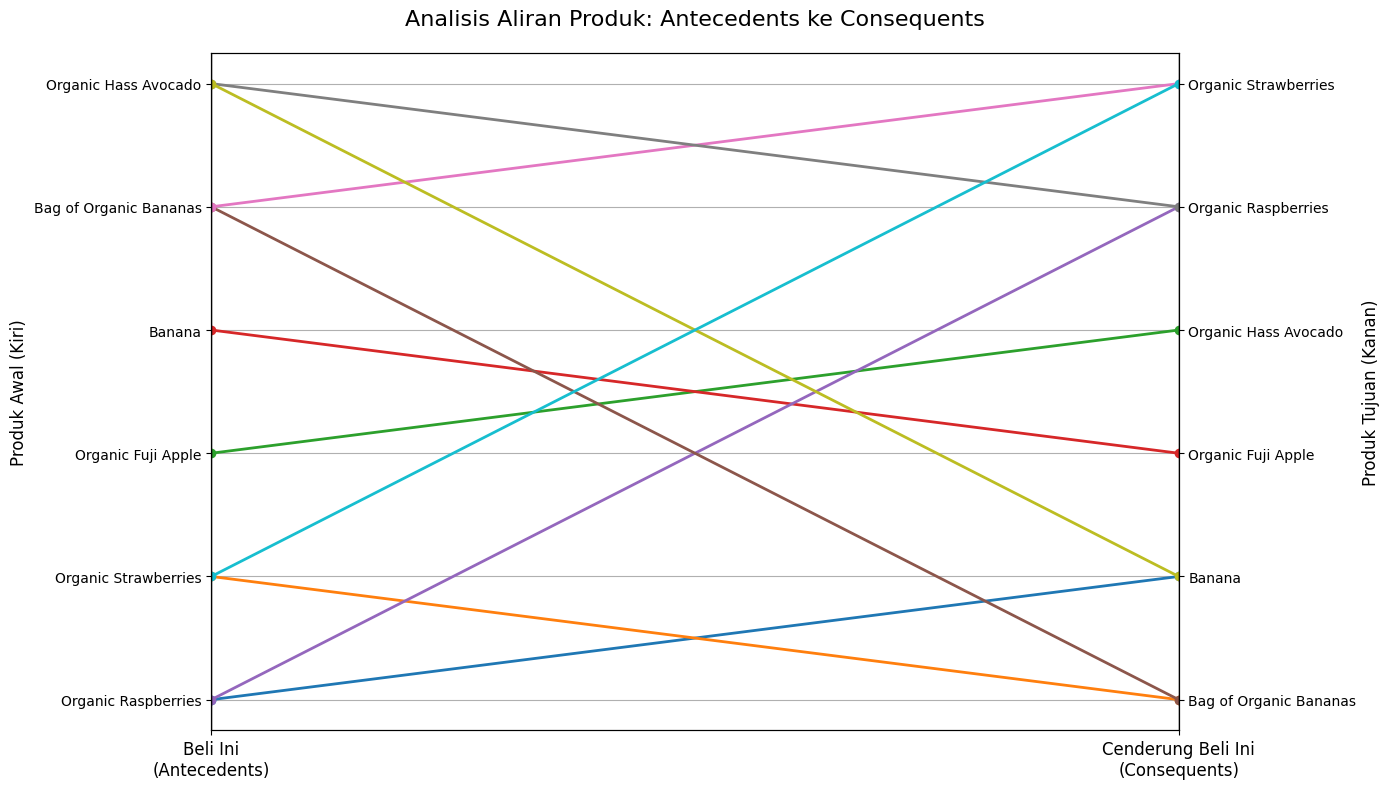

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# 1. Persiapan Data (Pastikan sudah jadi string)
rules_plot = rules.head(10).copy()
rules_plot['antecedents'] = rules_plot['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_plot['consequents'] = rules_plot['consequents'].apply(lambda x: ', '.join(list(x)))
rules_plot['rule_id'] = [f"Rule {i+1}" for i in range(len(rules_plot))]

# 2. Plotting
fig, ax = plt.subplots(figsize=(14, 8))

# Gambar Parallel Coordinates
parallel_coordinates(rules_plot[['antecedents', 'consequents', 'rule_id']], 
                     'rule_id', colormap='tab10', marker='o', linewidth=2, ax=ax)

# 3. TRIK: Menambahkan Label di Sisi Kanan (Consequents)
ax2 = ax.twinx() # Membuat sumbu Y bayangan di sebelah kanan
ax2.set_ylim(ax.get_ylim()) # Samakan skalanya dengan sumbu kiri
ax2.set_yticks(ax.get_yticks()) # Samakan posisi tick-nya

# Ambil label dari sisi kanan (Consequents) secara berurutan sesuai sumbu Y
# Kita mapping manual karena axis kanan perlu tahu posisi koordinat tiap produk
right_labels = sorted(rules_plot['consequents'].unique())
ax2.set_yticklabels(right_labels)

# 4. Finishing
ax.set_title("Analisis Aliran Produk: Antecedents ke Consequents", fontsize=16, pad=20)
ax.set_ylabel("Produk Awal (Kiri)", fontsize=12)
ax2.set_ylabel("Produk Tujuan (Kanan)", fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Beli Ini\n(Antecedents)', 'Cenderung Beli Ini\n(Consequents)'], fontsize=12)

ax.get_legend().remove()
plt.tight_layout()
plt.show()

In [ ]:
# # 1. Ubah frozenset (format asli mlxtend) menjadi string
# rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
# rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

# # 2. Filter hanya yang Lift-nya benar-benar kuat (> 1.5)
# rules_final = rules[rules['lift'] > 1.5]

# # 3. Ekspor ke CSV
# rules_final.to_csv(r'D:\Dhika Ramadhan Saputra\Data Analist\Full Project\Market Basket Analysis (MBA) & Bundling Strategy\data\hasil_algoritma\association_rules.csv', index=False)